# 📊 Descriptive Statistics Exercise
## World Happiness Report 2026
---

> **Petunjuk Umum:**  
> - Isi setiap cell kode di bawah ini.  
> - Tulis interpretasi Anda di cell Markdown yang telah disediakan (bertanda ✏️).  
> - Jangan hapus cell yang sudah ada — tambahkan cell baru jika diperlukan.  
> - Pastikan semua cell sudah dijalankan sebelum mengumpulkan.

---
## ⚙️ Import Library

In [1]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

print('Library berhasil di-import')

Library berhasil di-import


---
# Bagian 1 – Data Preparation & Eksplorasi Awal
Sebelum melakukan analisis, kita perlu memahami struktur dataset dan memastikan data siap digunakan.

## Task 1.1 – Load & Inspect Dataset

**a.** Download *Data for Table 2.1* dari [https://www.worldhappiness.report/data-sharing/](https://www.worldhappiness.report/data-sharing/)
lalu load ke dalam DataFrame bernama `df_whr`.

In [2]:
# a. Load dataset ke dalam df_whr
# Ganti path di bawah sesuai lokasi file Anda
df_whr = pd.read_excel('WHR26_Data_Figure_2.1.xlsx')
df_whr = df_whr.rename(columns={
    'Year': 'year',
    'Life evaluation (3-year average)': 'Life Ladder',
    'Explained by: Log GDP per capita': 'Log GDP per capita',
    'Explained by: Social support': 'Social support',
    'Explained by: Healthy life expectancy': 'Healthy life expectancy at birth',
    'Explained by: Freedom to make life choices': 'Freedom to make life choices',
    'Explained by: Generosity': 'Generosity',
    'Explained by: Perceptions of corruption': 'Perceptions of corruption',
})
print(f'Shape dataset: {df_whr.shape}')

Shape dataset: (2116, 13)


**b.** Tampilkan 5 baris pertama dan 5 baris terakhir dataset.

In [3]:
# b. Tampilkan 5 baris pertama
display(df_whr.head())

# 5 baris terakhir
display(df_whr.tail())

,year,Rank,Country name,Life Ladder,Lower whisker,Upper whisker,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


,year,Rank,Country name,Life Ladder,Lower whisker,Upper whisker,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
2111,2011,152,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2112,2011,153,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2113,2011,154,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2114,2011,155,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2115,2011,156,Togo,3.007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**c.** Cek dimensi dataset.

In [4]:
# c. Dimensi dataset
print(f'Jumlah baris  : {df_whr.shape[0]}')
print(f'Jumlah kolom  : {df_whr.shape[1]}')

Jumlah baris  : 2116
Jumlah kolom  : 13


**d.** Tampilkan daftar kolom beserta tipe datanya.

In [5]:
# d. Info kolom dan tipe data
df_whr.info()

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   year                              2116 non-null   int64  
 1   Rank                              2116 non-null   int64  
 2   Country name                      2116 non-null   str    
 3   Life Ladder                       2116 non-null   float64
 4   Lower whisker                     1022 non-null   float64
 5   Upper whisker                     1022 non-null   float64
 6   Log GDP per capita                1019 non-null   float64
 7   Social support                    1019 non-null   float64
 8   Healthy life expectancy at birth  1016 non-null   float64
 9   Freedom to make life choices      1017 non-null   float64
 10  Generosity                        1019 non-null   float64
 11  Perceptions of corruption         1018 non-null   float64
 12  Dystopia + residu

**e.** Cek missing values — tampilkan jumlah dan persentasenya.

In [6]:
# e. Missing values
missing = pd.DataFrame({
    'Jumlah Missing' : df_whr.isnull().sum(),
    'Persentase (%)'  : (df_whr.isnull().sum() / len(df_whr) * 100).round(2)
})
missing[missing['Jumlah Missing'] > 0]

,Jumlah Missing,Persentase (%)
Lower whisker,1094,51.70
Upper whisker,1094,51.70
Log GDP per capita,1097,51.84
Social support,1097,51.84
Healthy life expectancy at birth,1100,51.98
Freedom to make life choices,1099,51.94
Generosity,1097,51.84
Perceptions of corruption,1098,51.89
Dystopia + residual,1103,52.13


**f.** Buat DataFrame `df_idn` — data Indonesia tahun 2016–2026.

In [7]:
# f. Filter data Indonesia 2006–2023
df_idn = df_whr[df_whr['Country name'] == 'Indonesia'].sort_values('year').reset_index(drop=True)

print(f'Jumlah baris df_idn : {len(df_idn)}')
print(f"Rentang tahun       : {df_idn['year'].min()} - {df_idn['year'].max()}")
display(df_idn)

Jumlah baris df_idn : 14
Rentang tahun       : 2011 - 2025


,year,Rank,Country name,Life Ladder,Lower whisker,Upper whisker,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,2011,83,Indonesia,5.1590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012,76,Indonesia,5.3480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014,74,Indonesia,5.3990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,79,Indonesia,5.3140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016,81,Indonesia,5.2620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2017,96,Indonesia,5.0930,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2018,92,Indonesia,5.1920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2019,84,Indonesia,5.2856,5.192123,5.379077,0.891721,1.154801,0.610437,0.568161,0.542647,0.038279,1.479573
8,2020,82,Indonesia,5.3450,5.235000,5.454000,0.954000,0.786000,0.433000,0.598000,0.541000,0.046000,1.987000
9,2021,87,Indonesia,5.2400,5.139000,5.341000,1.382000,0.883000,0.539000,0.620000,0.468000,0.047000,1.300000


## Task 1.2 – Klasifikasi Variabel

**a.** Jelaskan perbedaan variabel **Kualitatif** dan **Kuantitatif**,  
beserta sub-kategori masing-masing (Nominal, Ordinal, Diskrit, Kontinu).

✏️ *Jawaban Anda di sini:*

- **Kualitatif** :
  - Nominal  : `Country name` — nama negara.
  - Ordinal  : `Rank`sebagai (peringkat berurutan).
- **Kuantitatif** :
  - Diskrit  : `year`, `Rank`
  - Kontinu  : `Life Ladder`, `Lower whisker`, `Upper whisker`, `Log GDP per capita`, `Social support`, `Healthy life expectancy at birth`, `Freedom to make life choices`, `Generosity`, `Perceptions of corruption`, `Dystopia + residual`


Kualitatif:
Nominal : Country name
Ordinal : Tidak ada
Kuantitatif:
Diskrit : Year, Rank
Kontinu : Life evaluation, Lower whisker, Upper whisker, Log GDP per capita, Social support, Healthy life expectancy, Freedom to make life choices, Generosity, Perceptions of corruption, Dystopia + residual

**b & c.** Klasifikasikan semua kolom `df_idn` ke dalam tabel klasifikasi.

In [8]:
# b & c. Tabel klasifikasi variabel
klasifikasi = pd.DataFrame({
    'nama_kolom': df_idn.columns.tolist(),

    'tipe_variabel': [
        'Kuantitatif - Diskrit',    # Year
        'Kuantitatif - Diskrit',    # Rank
        'Kualitatif - Nominal',     # Country name
        'Kuantitatif - Kontinu',    # Life evaluation
        'Kuantitatif - Kontinu',    # Lower whisker
        'Kuantitatif - Kontinu',    # Upper whisker
        'Kuantitatif - Kontinu',    # Log GDP per capita
        'Kuantitatif - Kontinu',    # Social support
        'Kuantitatif - Kontinu',    # Healthy life expectancy
        'Kuantitatif - Kontinu',    # Freedom
        'Kuantitatif - Kontinu',    # Generosity
        'Kuantitatif - Kontinu',    # Perceptions of corruption
        'Kuantitatif - Kontinu'     # Dystopia + residual
    ],

    'alasan': [
        'Tahun berupa bilangan bulat yang dapat dihitung',
        'Peringkat berupa bilangan bulat yang menunjukkan urutan',
        'Nama negara bersifat kategorik tanpa urutan',
        'Nilai evaluasi kehidupan berupa nilai numerik yang dapat memiliki desimal',
        'Batas bawah dari nilai evaluasi berupa nilai numerik kontinu',
        'Batas atas dari nilai evaluasi berupa nilai numerik kontinu',
        'Nilai GDP per kapita dalam bentuk logaritmik berupa data numerik kontinu',
        'Nilai dukungan sosial berupa data numerik kontinu',
        'Nilai harapan hidup sehat berupa data numerik kontinu',
        'Nilai kebebasan dalam menentukan pilihan hidup berupa data numerik kontinu',
        'Nilai kemurahan hati berupa data numerik kontinu',
        'Nilai persepsi terhadap korupsi berupa data numerik kontinu',
        'Nilai residual dan dystopia berupa data numerik kontinu'
    ]
})

display(klasifikasi)

,nama_kolom,tipe_variabel,alasan
0,year,Kuantitatif - Diskrit,Tahun berupa bilangan bulat yang dapat dihitung
1,Rank,Kuantitatif - Diskrit,Peringkat berupa bilangan bulat yang menunjukk...
2,Country name,Kualitatif - Nominal,Nama negara bersifat kategorik tanpa urutan
3,Life Ladder,Kuantitatif - Kontinu,Nilai evaluasi kehidupan berupa nilai numerik ...
4,Lower whisker,Kuantitatif - Kontinu,Batas bawah dari nilai evaluasi berupa nilai n...
5,Upper whisker,Kuantitatif - Kontinu,Batas atas dari nilai evaluasi berupa nilai nu...
6,Log GDP per capita,Kuantitatif - Kontinu,Nilai GDP per kapita dalam bentuk logaritmik b...
7,Social support,Kuantitatif - Kontinu,Nilai dukungan sosial berupa data numerik kontinu
8,Healthy life expectancy at birth,Kuantitatif - Kontinu,Nilai harapan hidup sehat berupa data numerik ...
9,Freedom to make life choices,Kuantitatif - Kontinu,Nilai kebebasan dalam menentukan pilihan hidup...


**d.** ✏️ *Mengapa klasifikasi variabel penting sebelum analisis statistik?*

> Klasifikasi variabel menentukan metode statistik apa yang valid digunakan. Mean, Std Dev, atau korelasi Pearson bermakna untuk data kuantitatif (interval/rasio) — menghitung "rata-rata" dari variabel nominal seperti `Country name` akan menghasilkan interpretasi yang keliru. Sebaliknya, variabel kategorik seperti nominal hanya bisa dianalisis dengan modus atau tabel frekuensi. Klasifikasi yang salah dapat membuat analis memilih uji atau visualisasi yang tidak sesuai, sehingga kesimpulan yang dihasilkan menjadi tidak valid atau menyesatkan.
> Klasifikasi variabel penting sebelum analisis statistik karena membantu menentukan metode analisis dan teknik pengolahan data yang tepat sesuai dengan jenis variabel yang digunakan. Dengan begitu, hasil analisis dapat lebih akurat dan tidak salah dalam interpretasi.

---
# Bagian 2 – Measure of Central Tendency
Ukuran pemusatan merangkum seluruh data dengan **satu nilai representatif**.
Tiga ukuran utama: **Mean**, **Median**, dan **Mode**.

## Task 2.1 – Konsep & Implementasi Central Tendency

**a.** Hitung Mean, Median, dan Mode untuk kolom `Life Ladder`.

In [9]:
# a. Central Tendency — Life Ladder
col = 'Life Ladder' 

mean_ll   = df_idn[col].mean()
median_ll = df_idn[col].median()
mode_ll   = df_idn[col].mode().iloc[0]

print(f'Mean   Life Ladder : {mean_ll:.4f}')
print(f'Median Life Ladder : {median_ll:.4f}')
print(f'Mode   Life Ladder : {mode_ll:.4f}')

Mean   Life Ladder : 5.3369
Median Life Ladder : 5.2998
Mode   Life Ladder : 5.6170


**b.** ✏️ *Ukuran central tendency mana yang paling tepat untuk `Life Ladder`? Jelaskan alasannya.*

> **Median** (5,2998) adalah ukuran yang paling representatif untuk `Life Ladder` Indonesia, dibanding Mean (5,3369) maupun Mode (5,6170). Alasannya, Median lebih tahan terhadap pengaruh nilai-nilai tinggi di ujung distribusi, sehingga lebih mencerminkan "titik tengah" kondisi kebahagiaan Indonesia secara keseluruhan selama 2011–2025.

**d.** Tampilkan central tendency semua kolom numerik sekaligus.

In [10]:
# d. Statistik deskriptif lengkap semua kolom numerik
numeric_cols = df_idn.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'year']

central = pd.DataFrame({
    'Mean'   : df_idn[numeric_cols].mean(),
    'Median' : df_idn[numeric_cols].median(),
    'Mode'   : df_idn[numeric_cols].mode().iloc[0],
}).round(4)

display(central)

,Mean,Median,Mode
Rank,83.4286,83.0000,83.0000
Life Ladder,5.3369,5.2998,5.6170
Lower whisker,5.3180,5.2350,5.1390
Upper whisker,5.5244,5.4540,5.3410
Log GDP per capita,1.2532,1.3610,0.8917
Social support,1.1111,1.1690,0.7860
Healthy life expectancy at birth,0.4725,0.4720,0.3140
Freedom to make life choices,0.7413,0.6630,0.5682
Generosity,0.4272,0.4220,0.2950
Perceptions of corruption,0.0430,0.0440,0.0330


**e.** Bandingkan Mean `Life Ladder` Indonesia vs rata-rata global pada tahun yang tersedia.

,Indonesia,Global Mean,Selisih
year,,,
2011,5.1590,5.3915,-0.2325
2012,5.3480,5.4187,-0.0707
2014,5.3990,5.3757,0.0233
2015,5.3140,5.3822,-0.0682
2016,5.2620,5.3540,-0.0920
2017,5.0930,5.3759,-0.2829
2018,5.1920,5.4071,-0.2151
2019,5.2856,5.4732,-0.1876
2020,5.3450,5.5328,-0.1878


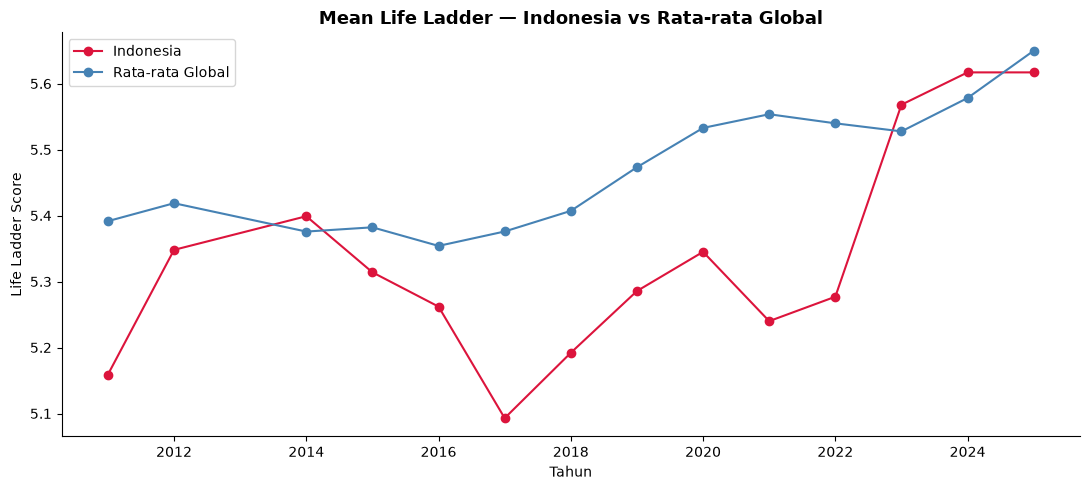

In [30]:
# e. Perbandingan Indonesia vs global
global_mean = df_whr.groupby('year')['Life Ladder'].mean().rename('Global Mean')
idn_series  = df_idn.set_index('year')['Life Ladder'].rename('Indonesia')

comparison = pd.concat([idn_series, global_mean], axis=1).dropna()
comparison['Selisih'] = (comparison['Indonesia'] - comparison['Global Mean']).round(4)

display(comparison.round(4))

# Visualisasi
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(comparison.index, comparison['Indonesia'], marker='o', color='crimson', label='Indonesia')
ax.plot(comparison.index, comparison['Global Mean'], marker='o', color='steelblue', label='Rata-rata Global')
ax.set_title('Mean Life Ladder — Indonesia vs Rata-rata Global', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Life Ladder Score')
ax.legend(); plt.tight_layout(); plt.show()

✏️ *Interpretasi perbandingan Indonesia vs global:*

> Pada sebagian besar tahun (2011–2022), skor Life Ladder Indonesia berada **di bawah** rata-rata global, dengan selisih terbesar terjadi pada 2021 (−0,31 poin) dan 2017 (−0,28 poin). Namun sejak **2023, posisi Indonesia mulai membaik melampaui rata-rata global** — selisih menjadi positif tipis (+0,04 poin pada 2023 dan 2024), sebelum kembali sedikit di bawah rata-rata pada 2025 (−0,03 poin). Pola ini menunjukkan bahwa kenaikan skor Indonesia dalam beberapa tahun terakhir bukan sekadar mengikuti tren global, melainkan mempercepat laju perbaikannya relatif terhadap rata-rata dunia

**f.** Fokus 5 tahun terakhir (2021–2025) — menjawab Q1: “Bagaimana tingkat kebahagiaan Indonesia berdasarkan WHR dalam 5 tahun terakhir?”(dengan pembanding sumber lain: BPS).

In [32]:
# f. Tren Life Ladder Indonesia -- 5 tahun terakhir (2021-2025)
last5 = [2021, 2022, 2023, 2024, 2025]
idn_5y = df_idn[df_idn['year'].isin(last5)][['year', 'Rank', 'Life Ladder']].reset_index(drop=True)
display(idn_5y)

# Persentase kenaikan skor & perubahan peringkat
skor_awal, skor_akhir = idn_5y['Life Ladder'].iloc[0], idn_5y['Life Ladder'].iloc[-1]
pct_change = (skor_akhir - skor_awal) / skor_awal * 100
rank_awal, rank_akhir = idn_5y['Rank'].iloc[0], idn_5y['Rank'].iloc[-1]

print(f"Skor Life Ladder : {skor_awal:.3f} ({idn_5y['year'].iloc[0]}) -> {skor_akhir:.3f} ({idn_5y['year'].iloc[-1]})")
print(f"Perubahan skor   : {pct_change:+.1f}%")
print(f"Peringkat global : #{rank_awal} -> #{rank_akhir}")
print(f"Peringkat terbaik dalam periode ini: #{idn_5y['Rank'].min()} (tahun {idn_5y.loc[idn_5y['Rank'].idxmin(),'year']})")

# Pembanding sumber lain: BPS - Indeks Kebahagiaan Nasional (skala 0-100, disurvei tiap 3 tahun)
bps = pd.DataFrame({
    'tahun_survei': [2017, 2021],
    'indeks_bps_0_100': [70.69, 71.49]
})
print("\nPembanding -- BPS Indeks Kebahagiaan Nasional:")
display(bps)
print("Sumber: Survei Pengukuran Tingkat Kebahagiaan (SPTK) BPS.")


,year,Rank,Life Ladder
0,2021,87,5.240
1,2022,84,5.277
2,2023,80,5.568
3,2024,83,5.617
4,2025,87,5.617


Skor Life Ladder : 5.240 (2021) -> 5.617 (2025)
Perubahan skor   : +7.2%
Peringkat global : #87 -> #87
Peringkat terbaik dalam periode ini: #80 (tahun 2023)

Pembanding -- BPS Indeks Kebahagiaan Nasional:


,tahun_survei,indeks_bps_0_100
0,2017,70.69
1,2021,71.49


Sumber: Survei Pengukuran Tingkat Kebahagiaan (SPTK) BPS.


✏️ *Jawaban Q1 — tingkat kebahagiaan Indonesia, 5 tahun terakhir:*

> Skor `Life Ladder` Indonesia meningkat dari **5,24 (2021)** menjadi **5,62 (2025)**, kenaikan sebesar **+7,2%** dalam 5 tahun (2021: 5,24 → 2022: 5,28 → 2023: 5,57 → 2024: 5,62 → 2025: 5,62). Namun peringkat global relatif stagnan: dari **#87 (2021)** sempat membaik ke **#80 (2023)**, lalu kembali ke **#87 (2025)** — skor Indonesia naik, tetapi negara lain juga membaik, bahkan lebih cepat, sehingga posisi relatif tidak banyak berubah.
>
> **Pembanding sumber lain:** Indeks Kebahagiaan Nasional BPS (skala 0–100, disurvei tiap 3 tahun lewat SPTK) juga menunjukkan tren naik: **70,69 (2017) → 71,49 (2021)**. Meski beda skala dan tahun pengukuran, arah trennya konsisten dengan data WHR — memperkuat kesimpulan bahwa kebahagiaan masyarakat Indonesia memang membaik pada periode ini, bukan sekadar artefak satu sumber data.

---
# Bagian 3 – Measure of Spread (Dispersi)
Ukuran penyebaran mengukur seberapa jauh data tersebar dari nilai pusatnya.

## Task 3.1 – Analisis Dispersi Data Indonesia

**a.** Hitung semua ukuran dispersi untuk `Life Ladder`.

In [12]:
# a. Ukuran dispersi — Life Ladder
col  = 'Life Ladder'
data = df_idn[col]

q1  = data.quantile(0.25)
q3  = data.quantile(0.75)
iqr = q3 - q1
std = data.std()

dispersi = {
    'Range'                     : data.max() - data.min(),
    'Variance'                  : data.var(),
    'Standard Deviation'        : std,
    'IQR (Q3 - Q1)'             : iqr,
    'Coefficient of Variation'  : (std / data.mean()) * 100,
}

for k, v in dispersi.items():
    print(f'{k:<30}: {v:.4f}')

Range                         : 0.5240
Variance                      : 0.0268
Standard Deviation            : 0.1637
IQR (Q3 - Q1)                 : 0.1408
Coefficient of Variation      : 3.0668


**c.** ✏️ *Bandingkan Std Dev Life Ladder Indonesia vs global — apa artinya bagi konsistensi kebahagiaan Indonesia?*

> Std Dev Life Ladder Indonesia (0,1637) jauh lebih kecil dibanding Std Dev global (1,1239) sekitar 7 kali lebih rendah. Ini normal dan tidak sepenuhnya bisa dibandingkan, Std Dev global mencerminkan variasi antar 150+ negara dengan kondisi sosial-ekonomi yang sangat beragam (dari negara termiskin hingga termakmur), sedangkan Std Dev Indonesia mencerminkan variasi skor dalam satu negara sepanjang waktu (14 tahun). Dari nilai Std Dev Indonesia yang kecil artinya: **tingkat kebahagiaan Indonesia relatif stabil dan konsisten dari tahun ke tahun**, tidak mengalami gejolak atau fluktuasi tajam dan perubahannya cenderung bertahap.

In [13]:
# c. Std Dev Indonesia vs global
std_idn    = df_idn['Life Ladder'].std()
std_global = df_whr['Life Ladder'].std()

print(f'Std Dev Indonesia : {std_idn:.4f}')
print(f'Std Dev Global    : {std_global:.4f}')

Std Dev Indonesia : 0.1637
Std Dev Global    : 1.1239


**d.** Hitung IQR untuk semua kolom numerik. Kolom mana yang memiliki sebaran terbesar?

In [14]:
# d. IQR semua kolom numerik
iqr_all = df_idn[numeric_cols].quantile(0.75) - df_idn[numeric_cols].quantile(0.25)
iqr_df  = iqr_all.sort_values(ascending=False).rename('IQR').to_frame().round(4)
display(iqr_df)


,IQR
Rank,6.0000
Lower whisker,0.3144
Upper whisker,0.3080
Log GDP per capita,0.2620
Freedom to make life choices,0.2395
Social support,0.1876
Dystopia + residual,0.1458
Generosity,0.1435
Life Ladder,0.1408
Healthy life expectancy at birth,0.0685


**e.** Hitung CV semua kolom numerik. Kolom mana yang paling stabil?

In [15]:
# e. Coefficient of Variation semua kolom numerik
cv_all = (df_idn[numeric_cols].std() / df_idn[numeric_cols].mean() * 100)
cv_df  = cv_all.sort_values().rename('CV (%)').to_frame().round(2)
display(cv_df)

,CV (%)
Life Ladder,3.07
Upper whisker,3.07
Lower whisker,3.26
Rank,6.98
Perceptions of corruption,16.90
Social support,18.38
Log GDP per capita,18.82
Healthy life expectancy at birth,19.44
Dystopia + residual,22.10
Generosity,22.83


✏️ *Kolom paling stabil berdasarkan CV adalah ... karena ...*

> kolom faktor **paling stabil** adalah **`Perceptions of corruption`** (CV = 16,90%) — kontribusinya terhadap skor kebahagiaan relatif konstan dari tahun ke tahun, mengindikasikan persepsi masyarakat terhadap korupsi tidak banyak berubah dalam jangka pendek. Sebaliknya, kolom **paling fluktuatif** adalah **`Freedom to make life choices`** (CV = 24,32%), menunjukkan kontribusi kebebasan memilih hidup terhadap kebahagiaan mengalami perubahan relatif besar dari tahun ke tahun — sejalan dengan temuan bahwa faktor ini juga yang paling banyak mendorong kenaikan skor pada 5 tahun terakhir.

## Task 3.2 – Deteksi & Analisis Outlier

**a.** Deteksi outlier `Life Ladder` menggunakan metode **IQR**.

In [16]:
# a. Deteksi outlier — metode IQR
col  = 'Life Ladder'
data = df_idn[col]

q1, q3 = data.quantile(0.25), data.quantile(0.75)
iqr    = q3 - q1
lower  = q1 - 1.5 * iqr
upper  = q3 + 1.5 * iqr

outliers_iqr = df_idn[(df_idn[col] < lower) | (df_idn[col] > upper)]

print(f'Batas bawah IQR : {lower:.4f}')
print(f'Batas atas  IQR : {upper:.4f}')
print(f'Jumlah outlier  : {len(outliers_iqr)}')
display(outliers_iqr[['year', col]])

Batas bawah IQR : 5.0344
Batas atas  IQR : 5.5974
Jumlah outlier  : 2


,year,Life Ladder
12,2024,5.617
13,2025,5.617


**b.** Deteksi outlier menggunakan **Z-Score** (|z| > 3). Bandingkan hasilnya.

In [17]:
# b. Deteksi outlier — metode Z-Score
z_scores = np.abs(stats.zscore(df_idn[col]))
outliers_zscore = df_idn[z_scores > 3]

print(f'Jumlah outlier Z-Score (|z|>3) : {len(outliers_zscore)}')
display(outliers_zscore[['year', col]])

print(f'\nPerbandingan:')
print(f'  IQR    : {len(outliers_iqr)} outlier')
print(f'  Z-Score: {len(outliers_zscore)} outlier')

Jumlah outlier Z-Score (|z|>3) : 0


,year,Life Ladder



Perbandingan:
  IQR    : 2 outlier
  Z-Score: 0 outlier


**c.** Visualisasi outlier dengan Boxplot.

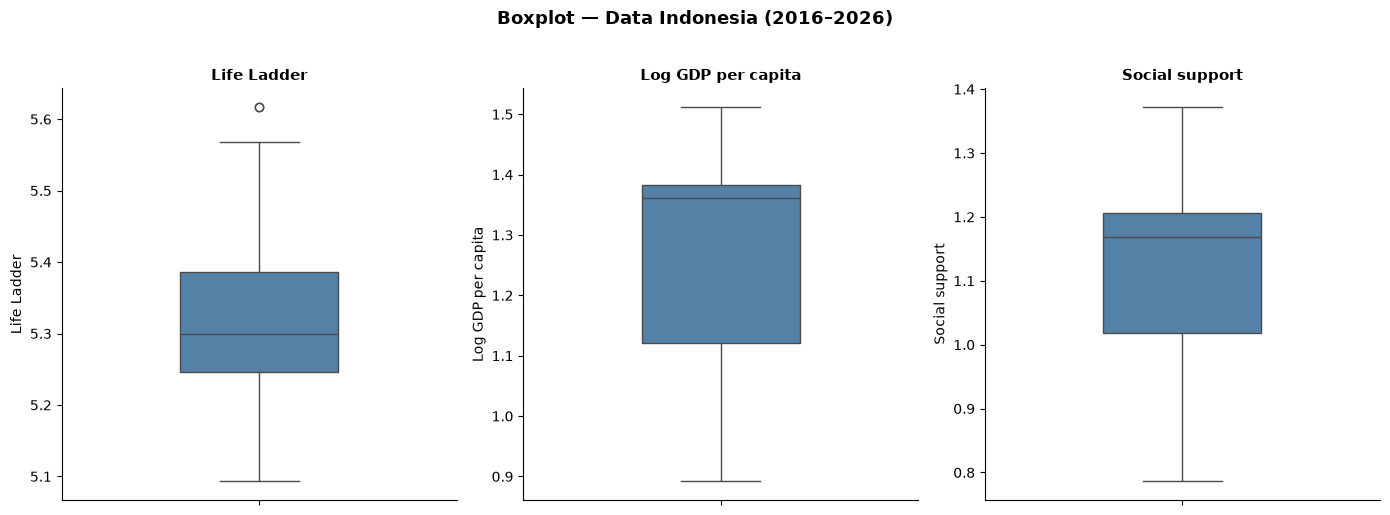

In [18]:
# c. Boxplot — Life Ladder, Log GDP per capita, Social support
cols_box = ['Life Ladder', 'Log GDP per capita', 'Social support']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, c in zip(axes, cols_box):
    sns.boxplot(y=df_idn[c], ax=ax, color='steelblue', width=0.4)
    ax.set_title(c, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

fig.suptitle('Boxplot — Data Indonesia (2016–2026)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**d.** ✏️ *Identifikasi tahun outlier dan jelaskan kemungkinan penyebabnya.*

> Metode IQR mengidentifikasi 2024 dan 2025 (masing-masing 5,617) sebagai outlier atas berada di luar batas atas 5,5974. Kemungkinan penyebabnya adalah **pemulihan pascapandemi COVID-19** yang berlangsung bertahap: setelah skor sempat tertekan pada masa pandemi dan sebelumnya (2016–2022), ekonomi dan mobilitas sosial masyarakat Indonesia pulih signifikan pada 2023–2025, bertepatan dengan naiknya kontribusi faktor Kebebasan Memilih Hidup dan Dukungan Sosial. Pada metode **Z-Score tidak mendeteksi outlier apa pun**  karena ambang |z|>3 relatif kecil (std hanya 0,16 pada n=14), sehingga nilai-nilai yang "ekstrem" secara IQR (relatif terhadap kuartil lokal) belum cukup jauh dari mean untuk dianggap ekstrem secara Z-Score.

---
# Bagian 4 – Analisis Distribusi Data
Distribusi data menggambarkan pola penyebaran nilai — apakah simetris, skewed kanan, atau skewed kiri.

## Task 4.1 – Eksplorasi Distribusi

**a.** Buat Histogram untuk semua kolom numerik dalam satu figure.

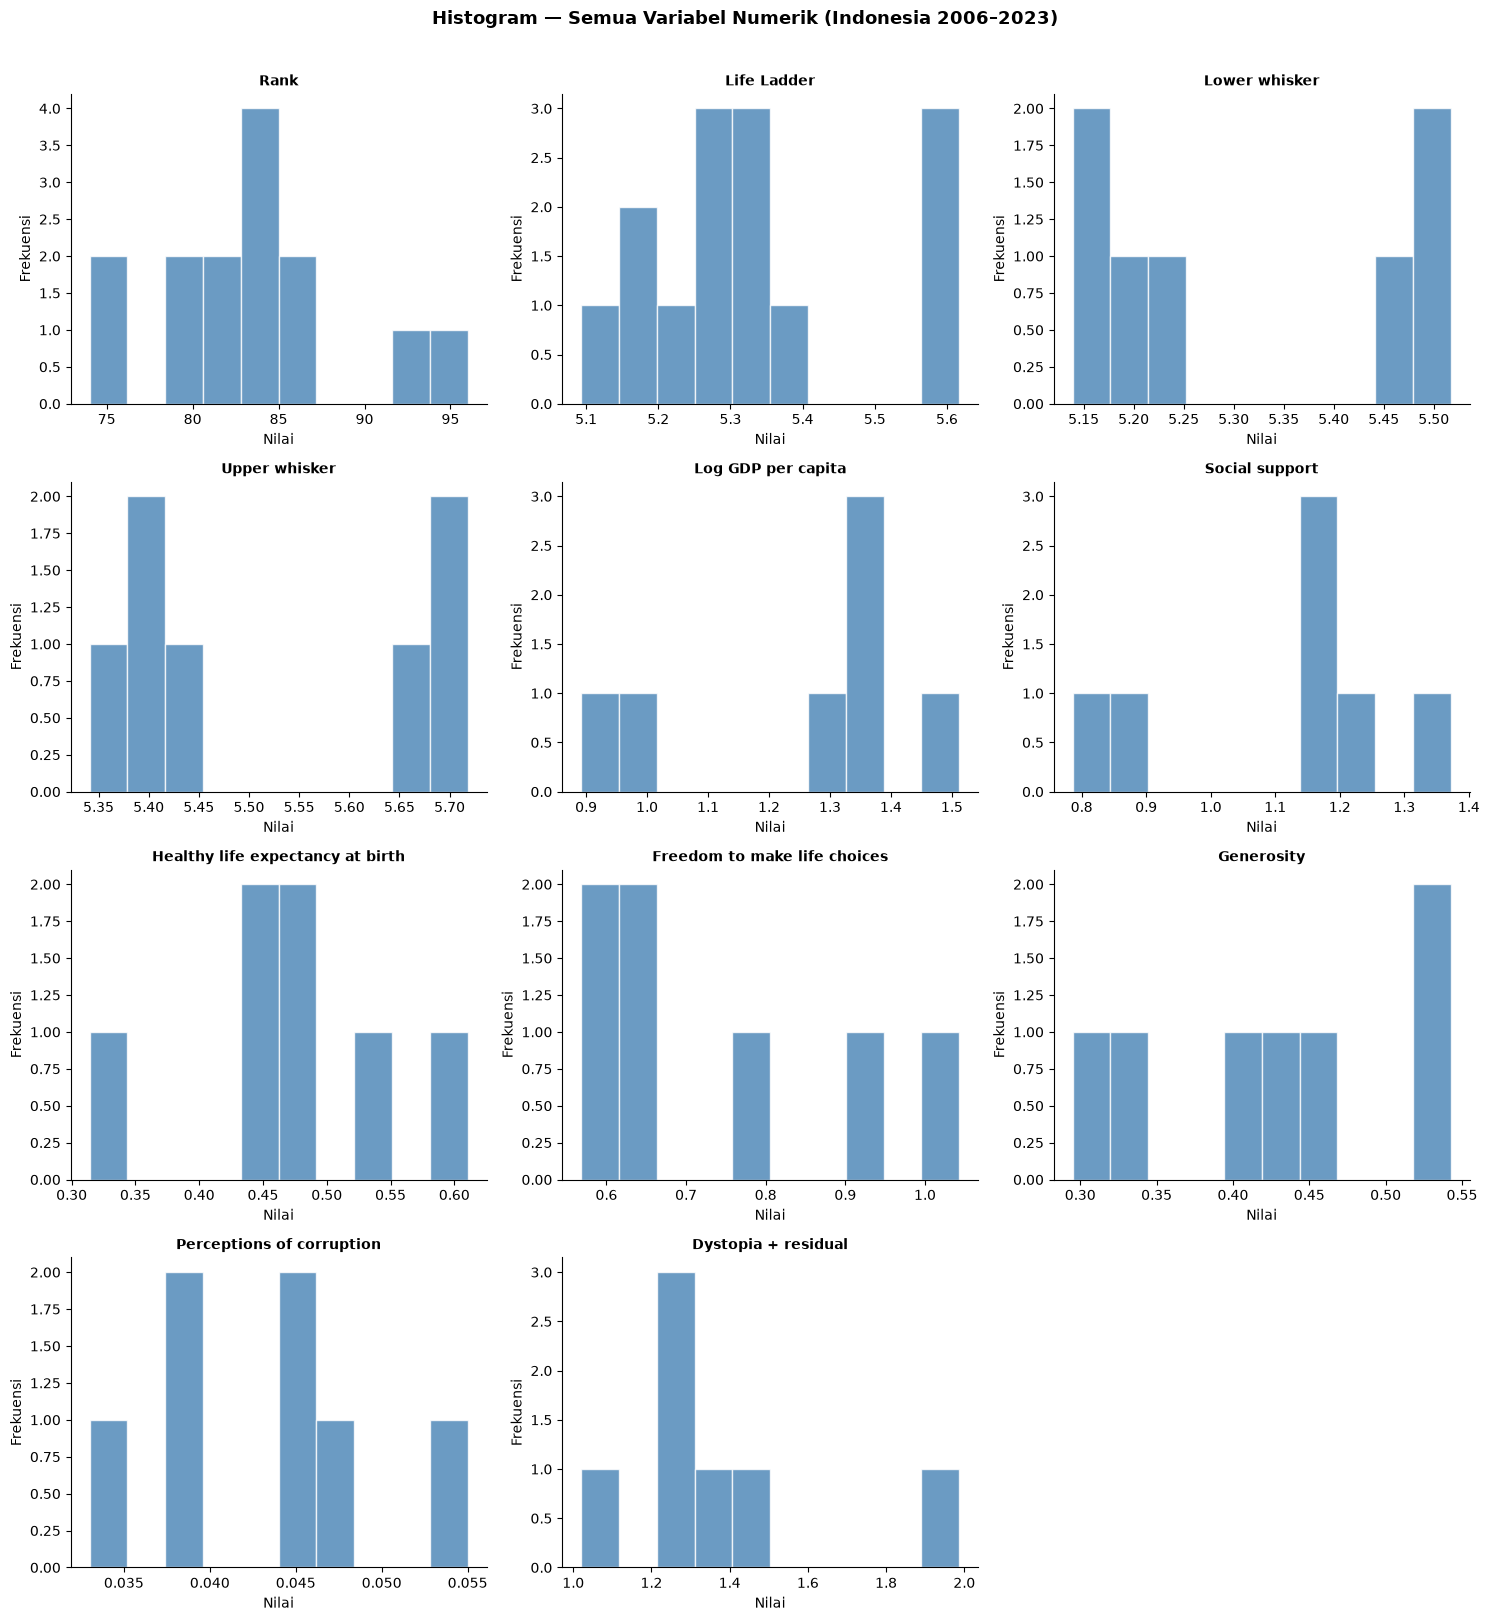

In [19]:
# a. Histogram semua kolom numerik
n     = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_idn[col].dropna(), bins=10, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai'); axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histogram — Semua Variabel Numerik (Indonesia 2006–2023)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**b.** Hitung Skewness dan Kurtosis setiap kolom numerik.

In [20]:
# b. Skewness dan Kurtosis
sk_kurt = pd.DataFrame({
    'Skewness' : df_idn[numeric_cols].skew(),
    'Kurtosis' : df_idn[numeric_cols].kurt(),
}).round(4)

display(sk_kurt)

,Skewness,Kurtosis
Rank,0.5966,0.6392
Life Ladder,0.6481,-0.3791
Lower whisker,0.3007,-2.5434
Upper whisker,0.2649,-2.5161
Log GDP per capita,-0.9084,-0.8304
Social support,-0.7170,-0.3710
Healthy life expectancy at birth,-0.3395,1.2536
Freedom to make life choices,0.9010,-0.6138
Generosity,-0.0980,-1.4214
Perceptions of corruption,0.3349,-0.0421


**c.** ✏️ *Tentukan distribusi setiap kolom berdasarkan nilai skewness dan interpretasikan:*

| Kolom | Skewness | Jenis Distribusi | Interpretasi |
|-------|----------|------------------|--------------|
| Life Ladder | +0,648 | Right-skewed (ringan) | Beberapa tahun terakhir (2024–2025) bernilai tinggi menarik ekor distribusi ke kanan |
| Log GDP per capita | −0,908 | Left-skewed | Sebagian besar tahun berkontribusi tinggi; beberapa tahun awal (kontribusi rendah) menarik ekor ke kiri |
| Social support | −0,717 | Left-skewed | Serupa dengan GDP — mayoritas tahun berkontribusi tinggi, minoritas tahun awal rendah |
| Healthy life expectancy | −0,340 | Left-skewed (ringan) | Distribusi sedikit condong ke kiri |
| Freedom to make life choices | +0,901 | Right-skewed | Beberapa tahun terakhir bernilai jauh lebih tinggi dari mayoritas tahun lain |
| Generosity | −0,098 | Mendekati simetris | Nilai skewness sangat kecil, distribusi relatif seimbang, artinya tidak ada lonjakan atau penurunan yang ekstrem dari tahun ke tahun |
| Perceptions of corruption | +0,335 | Right-skewed (ringan) | Sedikit condong ke kanan, distribusi relatif mendekati simetris |

**d.** Buat KDE Plot overlay di atas Histogram untuk `Life Ladder` dan `Log GDP per capita`.

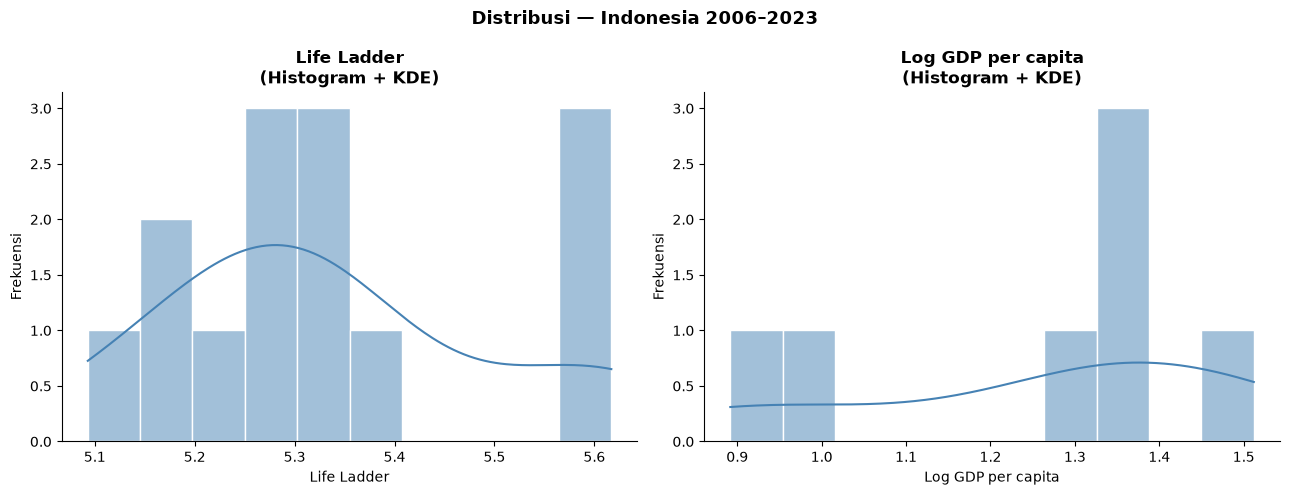

In [21]:
# d. Histogram + KDE — Life Ladder & Log GDP per capita
cols_kde = ['Life Ladder', 'Log GDP per capita']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, cols_kde):
    sns.histplot(df_idn[col].dropna(), bins=10, kde=True, ax=ax,
                 color='steelblue', edgecolor='white')
    ax.set_title(f'{col}\n(Histogram + KDE)', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Frekuensi')

plt.suptitle('Distribusi — Indonesia 2006–2023', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**e.** Bandingkan distribusi `Life Ladder` Indonesia vs global tahun 2025.

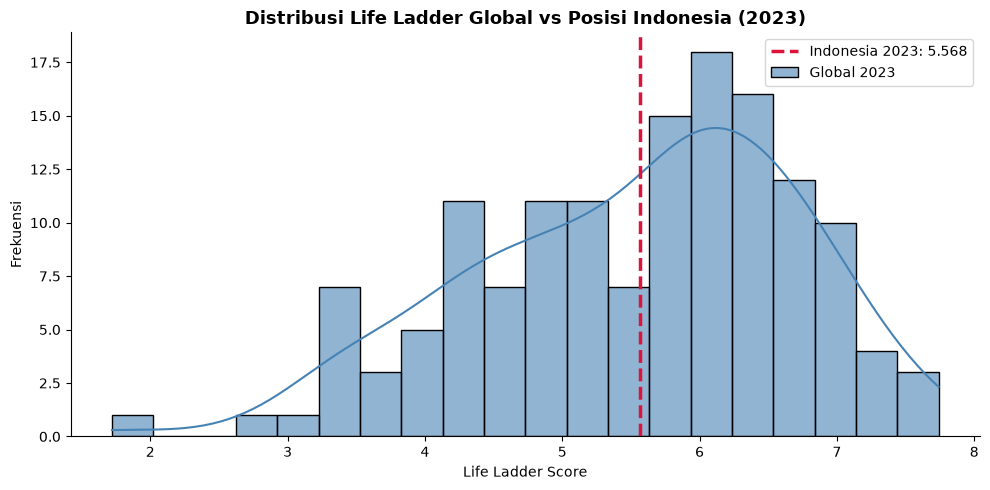

In [22]:
# e. Indonesia vs Global — Life Ladder 2023
global_2023 = df_whr[df_whr['year'] == 2023]['Life Ladder'].dropna()
idn_2023    = df_idn[df_idn['year'] == 2023]['Life Ladder']

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(global_2023, bins=20, kde=True, ax=ax, color='steelblue',
             alpha=0.6, label='Global 2023')

if len(idn_2023) > 0:
    ax.axvline(idn_2023.values[0], color='crimson', linewidth=2.5,
               linestyle='--', label=f'Indonesia 2023: {idn_2023.values[0]:.3f}')

ax.set_title('Distribusi Life Ladder Global vs Posisi Indonesia (2023)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score'); ax.set_ylabel('Frekuensi')
ax.legend(); plt.tight_layout(); plt.show()

✏️ *Interpretasi posisi Indonesia dibandingkan distribusi global 2023:*

> Jawaban Anda di sini...

---
# Bagian 5 – Visualisasi & Analisis Hubungan Antar Variabel
Visualisasi yang tepat membantu mengkomunikasikan temuan secara efektif.

## Task 5.1 – Visualisasi Tren & Komparasi

**a.** Line Chart tren `Life Ladder` Indonesia 2016–2026 dengan anotasi titik tertinggi & terendah.

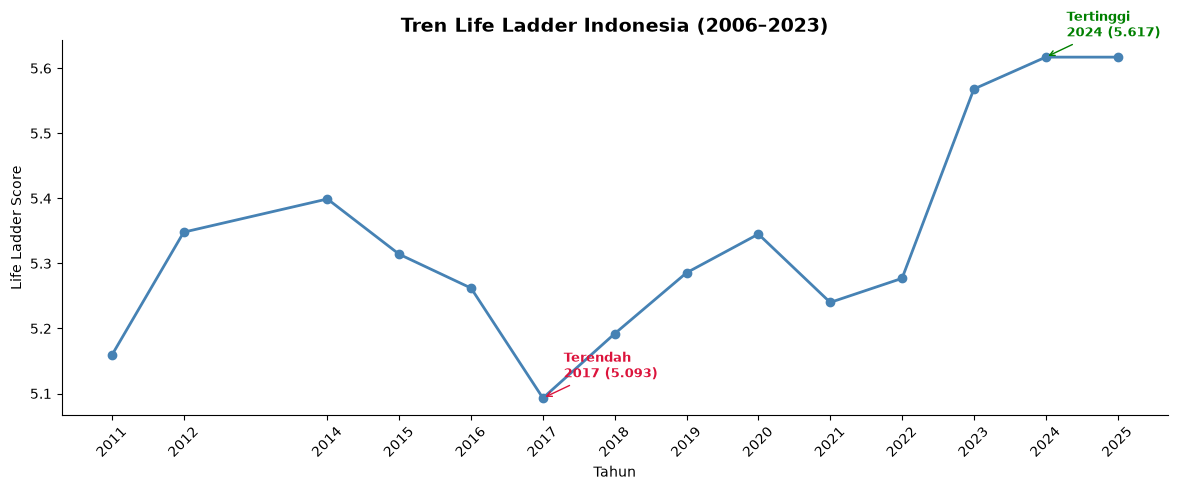

In [23]:
# a. Line Chart — Tren Life Ladder Indonesia
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_idn['year'], df_idn['Life Ladder'], marker='o',
        color='steelblue', linewidth=2, markersize=6)

# Anotasi titik tertinggi dan terendah
idx_max = df_idn['Life Ladder'].idxmax()
idx_min = df_idn['Life Ladder'].idxmin()

for idx, label, color in [(idx_max, 'Tertinggi', 'green'), (idx_min, 'Terendah', 'crimson')]:
    ax.annotate(
        f"{label}\n{df_idn.loc[idx, 'year']} ({df_idn.loc[idx, 'Life Ladder']:.3f})",
        xy=(df_idn.loc[idx, 'year'], df_idn.loc[idx, 'Life Ladder']),
        xytext=(15, 15), textcoords='offset points',
        fontsize=9, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color)
    )

ax.set_title('Tren Life Ladder Indonesia (2006–2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Life Ladder Score')
ax.set_xticks(df_idn['year']); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

**b.** Bar Chart — rata-rata `Life Ladder` negara-negara ASEAN tahun 2023.

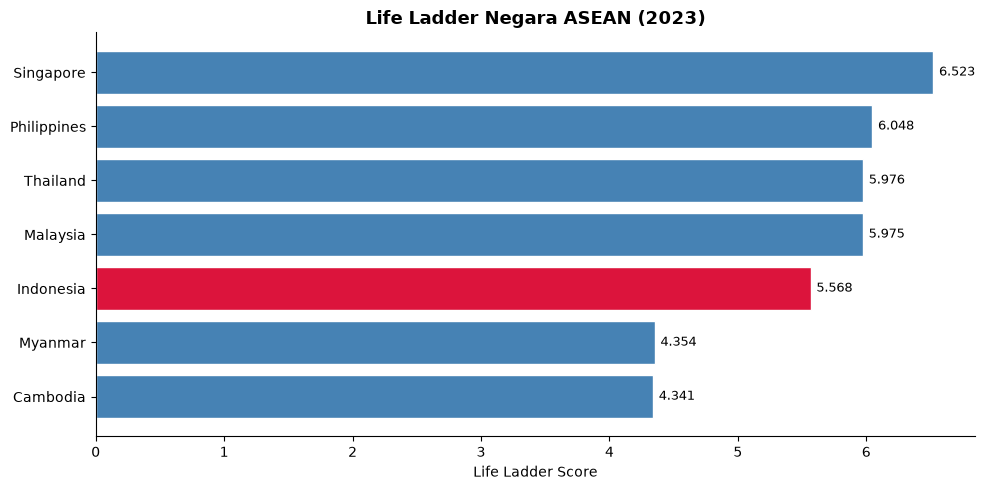

In [24]:
# b. Bar Chart — Life Ladder ASEAN 2023
asean = ['Indonesia', 'Thailand', 'Philippines', 'Vietnam', 'Malaysia',
         'Singapore', 'Myanmar', 'Cambodia', 'Laos', 'Brunei Darussalam']

asean_2023 = df_whr[(df_whr['Country name'].isin(asean)) &
                     (df_whr['year'] == 2023)][['Country name', 'Life Ladder']]\
             .sort_values('Life Ladder', ascending=True)

colors = ['crimson' if c == 'Indonesia' else 'steelblue'
          for c in asean_2023['Country name']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(asean_2023['Country name'], asean_2023['Life Ladder'],
               color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_title('Life Ladder Negara ASEAN (2023)', fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score')
plt.tight_layout(); plt.show()

**c.** ✏️ *Jelaskan kapan sebaiknya menggunakan Line Chart vs Bar Chart:*

> **Line Chart** paling tepat digunakan untuk menunjukkan **tren/perubahan suatu variabel kontinu dari waktu ke waktu** (data time-series), karena garis penghubung antar titik secara visual menunjukkan arah pergerakan (naik/turun). **Bar Chart** digunakan untuk **membandingkan besaran antar kategori yang terpisah/diskrit** (misalnya antar negara, antar faktor, atau antar kelompok), di mana urutan sumbu-x tidak selalu memiliki makna kontinu — contohnya perbandingan rata-rata Life Ladder antar negara ASEAN, atau perbandingan delta kontribusi antar faktor. Gunakan Line Chart jika sumbu-x adalah waktu/urutan kontinu; gunakan Bar Chart jika sumbu-x adalah kategori.

**d.** Heatmap nilai semua variabel numerik Indonesia per tahun.

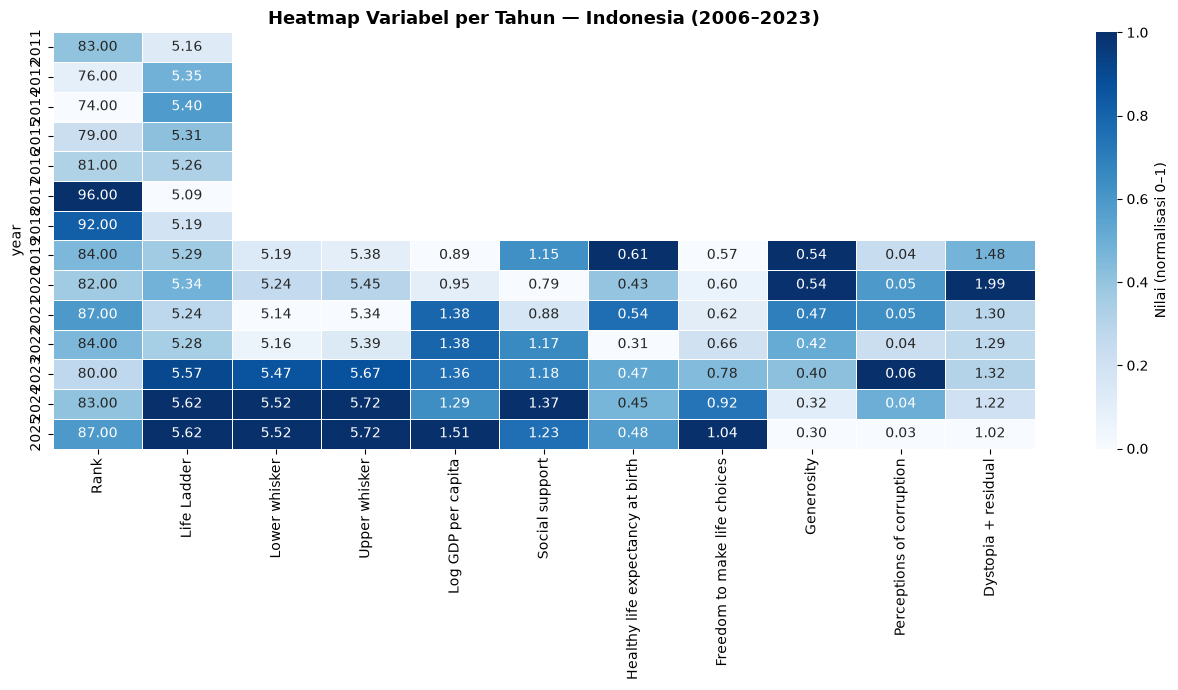

In [25]:
# d. Heatmap — nilai variabel per tahun
heatmap_data = df_idn.set_index('year')[numeric_cols]

# Normalisasi 0–1 agar skala sebanding
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(2), fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Nilai (normalisasi 0–1)'})
ax.set_title('Heatmap Variabel per Tahun — Indonesia (2006–2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Task 5.2 – Analisis Korelasi & Scatter Plot

**a & b.** Scatter Plot 4 pasang variabel + Koefisien Korelasi Pearson.

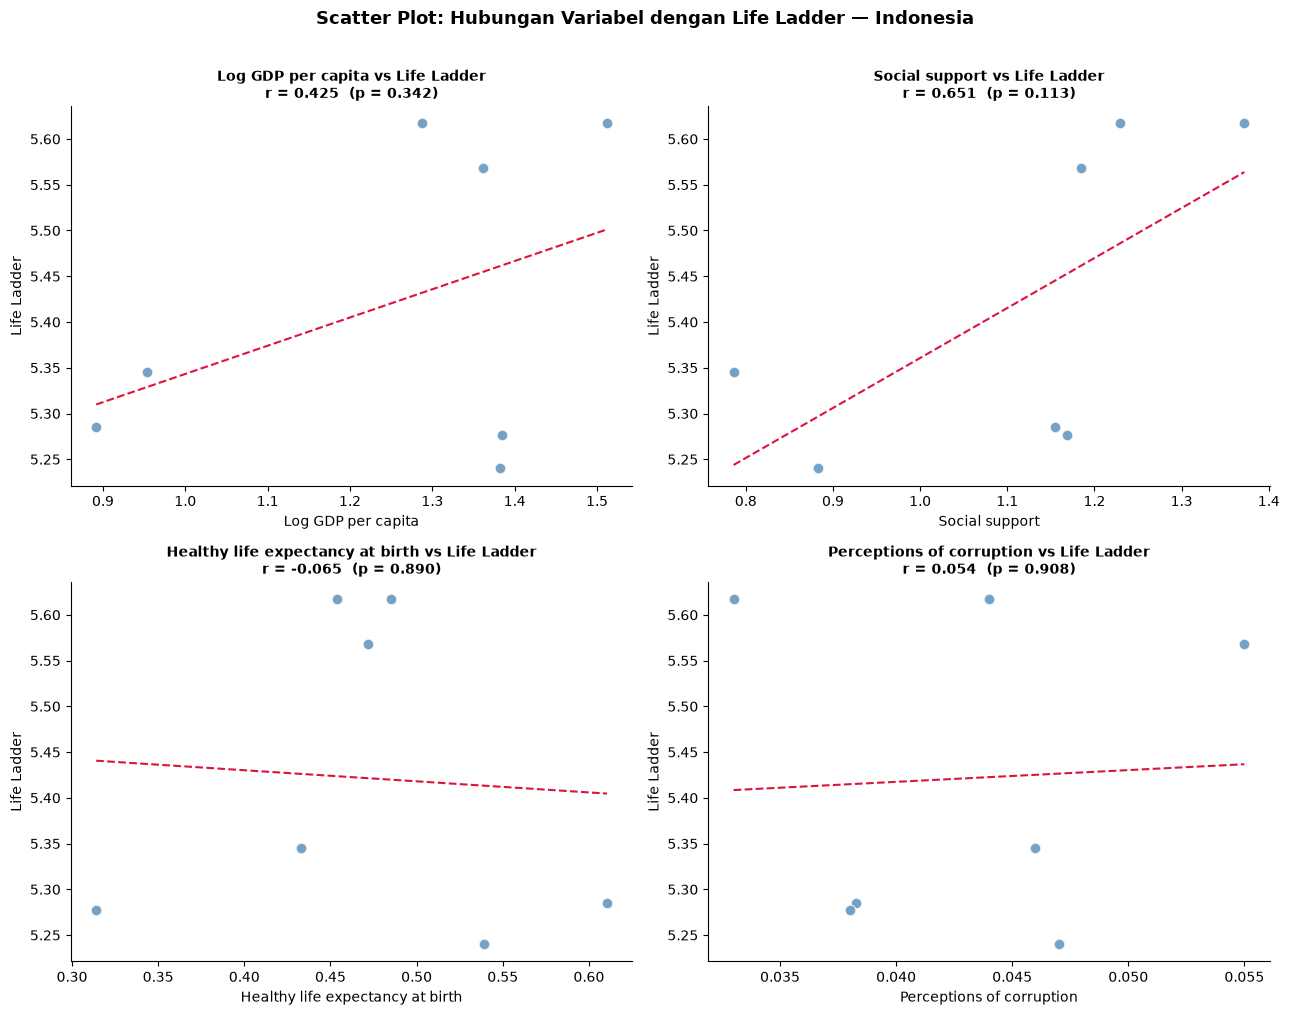

In [26]:
# a & b. Scatter Plot + Korelasi Pearson
pairs = [
    ('Log GDP per capita',              'Life Ladder'),
    ('Social support',                  'Life Ladder'),
    ('Healthy life expectancy at birth', 'Life Ladder'),
    ('Perceptions of corruption',        'Life Ladder'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, pairs):
    valid = df_idn[[x_col, y_col]].dropna()
    r, p  = stats.pearsonr(valid[x_col], valid[y_col])

    ax.scatter(valid[x_col], valid[y_col], color='steelblue', alpha=0.75, edgecolor='white', s=60)

    # Trend line
    m, b = np.polyfit(valid[x_col], valid[y_col], 1)
    x_line = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5, linestyle='--')

    ax.set_title(f'{x_col} vs Life Ladder\nr = {r:.3f}  (p = {p:.3f})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)

plt.suptitle('Scatter Plot: Hubungan Variabel dengan Life Ladder — Indonesia',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

✏️ *Interpretasi korelasi setiap pasang variabel:*

| Pasang Variabel | r | Interpretasi |
|---|---|---|
| Log GDP vs Life Ladder | 0,425 | Korelasi positif sedang -> semakin tinggi kontribusi GDP per kapita, cenderung semakin tinggi skor kebahagiaan, namun hubungannya tidak terlalu kuat |
| Social support vs Life Ladder | 0,651 | Korelasi positif kuat -> dukungan sosial yang lebih tinggi cenderung diiringi kebahagiaan yang lebih tinggi |
| Life expectancy vs Life Ladder | −0,065 | Tidak berkorelasi -> kontribusi harapan hidup sehat tidak menunjukkan pola hubungan yang jelas dengan skor kebahagiaan pada data Indonesia |
| Corruption vs Life Ladder | 0,055 | Tidak berkorelasi -> kontribusi persepsi korupsi hampir tidak berhubungan secara linear dengan skor kebahagiaan pada rentang data ini |

**c.** Correlation Heatmap semua variabel numerik.

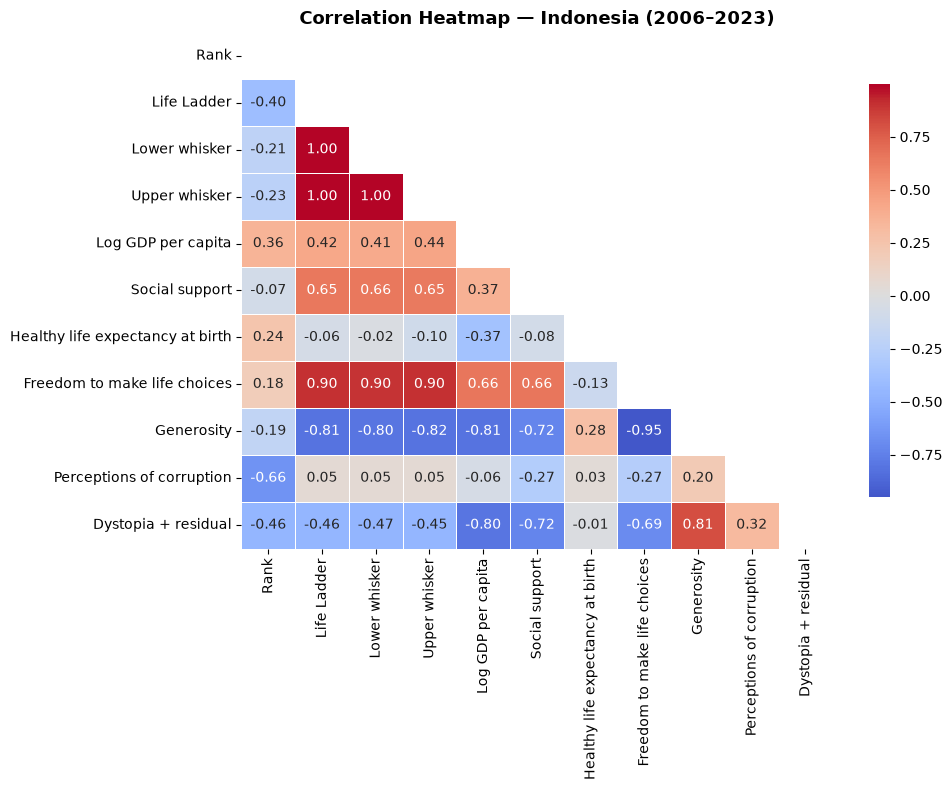

In [27]:
# c. Correlation Heatmap
corr = df_idn[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Indonesia (2006–2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

✏️ *Variabel yang paling berkorelasi dengan Life Ladder adalah ... dengan nilai r = ...*

> Variabel yang paling berkorelasi dengan `Life Ladder` Indonesia adalah **`Freedom to make life choices`** dengan **r = +0,901** (di luar Lower/Upper whisker yang secara matematis nyaris identik dengan Life Ladder itu sendiri).
> Korelasi positif yang sangat kuat ini mengindikasikan bahwa kenaikan kontribusi kebebasan memilih hidup terhadap skor sangat berhubungan dengan kenaikan skor kebahagiaan secara keseluruhan. `Generosity` berkorelasi **negatif kuat** (r = −0,812) — semakin tinggi skor kebahagiaan Indonesia dari waktu ke waktu, semakin rendah kontribusi kedermawanan terhadap skor tersebut, pola yang berlawanan arah.

**d.** ✏️ *Jelaskan perbedaan korelasi dan kausalitas, serta berikan contoh dari data WHR ini:*

> **Korelasi** hanya mengukur seberapa kuat dan searah mana dua variabel bergerak bersama secara statistik, sedangkan **kausalitas** berarti perubahan pada satu variabelmenyebabkan perubahan pada variabel lain. Data observasional seperti WHR tidak bisa membuktikan kausalitas hanya dari nilai korelasi.
>
> **Contoh dari data ini:** `Freedom to make life choices` berkorelasi sangat kuat dengan `Life Ladder` (r=0,90), tetapi ini tidak membuktikan bahwa kebebasan memilih hidup secara langsung menyebabkan kenaikan kebahagiaan. Bisa jadi arah sebabnya terbalik (masyarakat yang lebih bahagia/sejahtera cenderung menilai kebebasannya lebih tinggi), atau ada **faktor lain** (misalnya perbaikan ekonomi dan stabilitas politik) yang secara bersamaan meningkatkan baik kebebasan maupun kebahagiaan tanpa satu menyebabkan yang lain secara langsung.


**e.** Perubahan kontribusi tiap faktor 5 tahun terakhir (2021 vs 2025) — menjawab **Q2**: *“Faktor apa yang memengaruhi skor kebahagiaan Indonesia dalam 5 tahun terakhir?”*

In [33]:
# e. Delta kontribusi faktor Indonesia -- 2021 vs 2025
faktor_cols = ['Log GDP per capita', 'Social support', 'Healthy life expectancy at birth',
               'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

idn_2021 = df_idn[df_idn['year'] == 2021][faktor_cols].iloc[0]
idn_2025 = df_idn[df_idn['year'] == 2025][faktor_cols].iloc[0]

delta_faktor = (idn_2025 - idn_2021).sort_values(ascending=False)
delta_df = delta_faktor.round(3).rename('Delta (2025 - 2021)').to_frame()
display(delta_df)

print(f"Faktor pendorong terbesar : {delta_faktor.index[0]} ({delta_faktor.iloc[0]:+.3f})")
print(f"Faktor yang paling melemah: {delta_faktor.index[-1]} ({delta_faktor.iloc[-1]:+.3f})")


,Delta (2025 - 2021)
Freedom to make life choices,0.423
Social support,0.346
Log GDP per capita,0.130
Perceptions of corruption,-0.014
Healthy life expectancy at birth,-0.054
Generosity,-0.173


Faktor pendorong terbesar : Freedom to make life choices (+0.423)
Faktor yang paling melemah: Generosity (-0.173)


✏️ *Jawaban Q2 — faktor yang memengaruhi kebahagiaan Indonesia, 5 tahun terakhir:*

> Tiga faktor paling **mendorong** kenaikan skor (2025 vs 2021): **Kebebasan Memilih Hidup (+0,423)**, **Dukungan Sosial (+0,346)**, dan **Log GDP per Kapita (+0,130)**. Tiga faktor yang **melemah**: **Kedermawanan/Generosity (−0,173)**, **Harapan Hidup Sehat (−0,054)**, dan **Persepsi Korupsi (−0,014, nyaris stagnan)**.
>
> Temuan ini konsisten dengan analisis korelasi jangka panjang (2011–2025) pada bagian sebelumnya, di mana `Freedom to make life choices` (r=+0,90) dan `Social support` (r=+0,65) adalah dua faktor dengan korelasi terkuat terhadap `Life Ladder`, sementara `Generosity` justru berkorelasi negatif (r=−0,81) — memperkuat kesimpulan bahwa **dimensi sosial dan kebebasan personal**, bukan ekonomi, menjadi pendorong utama kenaikan kebahagiaan Indonesia 5 tahun terakhir.

---
# Bagian 6 – Insight & Pelaporan
Analisis yang baik tidak hanya menghasilkan angka, tetapi juga **cerita bermakna** dari data.

## Task 6.1 – Ringkasan Analisis & Insight

**a.** ✏️ *Tuliskan minimal 5 insight dari analisis Anda:*

1. **Insight 1:** ...
2. **Insight 2:** ...
3. **Insight 3:** ...
4. **Insight 4:** ...
5. **Insight 5:** ...

**b.** Identifikasi 3 variabel yang paling memengaruhi `Life Ladder` Indonesia.

In [28]:
# b. Top 3 variabel paling berkorelasi dengan Life Ladder
corr_ll = df_idn[numeric_cols].corr()['Life Ladder']\
           .drop('Life Ladder').abs().sort_values(ascending=False)

print('Top variabel berkorelasi dengan Life Ladder:')
display(corr_ll.head(3).to_frame('|Korelasi| dengan Life Ladder').round(4))

Top variabel berkorelasi dengan Life Ladder:


,|Korelasi| dengan Life Ladder
Upper whisker,0.9992
Lower whisker,0.9992
Freedom to make life choices,0.9006


✏️ *Interpretasi 3 variabel teratas:*

> Jawaban Anda di sini...

**c.** ✏️ *Apakah tren kebahagiaan Indonesia meningkat, menurun, atau stagnan?*

> Dukung dengan data dan visualisasi di atas...

**d.** Peringkat Indonesia di antara negara ASEAN berdasarkan rata-rata `Life Ladder`.

In [29]:
# d. Ranking Indonesia di ASEAN (semua tahun tersedia)
asean_avg = df_whr[df_whr['Country name'].isin(asean)]\
             .groupby('Country name')['Life Ladder']\
             .mean().sort_values(ascending=False)\
             .reset_index()
asean_avg.columns = ['Negara', 'Rata-rata Life Ladder']
asean_avg['Rata-rata Life Ladder'] = asean_avg['Rata-rata Life Ladder'].round(3)
asean_avg.index += 1
asean_avg.index.name = 'Peringkat'

display(asean_avg)
rank = asean_avg[asean_avg['Negara'] == 'Indonesia'].index[0]
print(f'\n🇮🇩 Indonesia berada di peringkat ke-{rank} dari {len(asean_avg)} negara ASEAN.')

,Negara,Rata-rata Life Ladder
Peringkat,,
1,Singapore,6.522
2,Thailand,6.130
3,Malaysia,5.824
4,Philippines,5.602
5,Indonesia,5.337
6,Myanmar,4.438
7,Cambodia,4.361



🇮🇩 Indonesia berada di peringkat ke-5 dari 7 negara ASEAN.


Perbandingan Indonesia vs negara ASEAN lain — **khusus 5 tahun terakhir (2021–2025)**, menjawab **Q3**: *“Bagaimana skor kebahagiaan Indonesia dibanding negara lain di Asia Tenggara dalam 5 tahun terakhir?”*

In [35]:
# e. Perbandingan Indonesia vs ASEAN -- 5 tahun terakhir (2021-2025)
last5 = [2021, 2022, 2023, 2024, 2025]
sea_5y = df_whr[(df_whr['Country name'].isin(asean)) & (df_whr['year'].isin(last5))]

# Rata-rata Life Ladder 5 tahun terakhir per negara
asean_avg_5y = (sea_5y.groupby('Country name')['Life Ladder']
                       .mean()
                       .sort_values(ascending=False)
                       .round(3)
                       .reset_index())
asean_avg_5y.columns = ['Negara', 'Rata-rata Life Ladder (2021-2025)']
asean_avg_5y.index += 1
asean_avg_5y.index.name = 'Peringkat'
display(asean_avg_5y)


,Negara,Rata-rata Life Ladder (2021-2025)
Peringkat,,
1,Singapore,6.548
2,Thailand,6.046
3,Philippines,5.958
4,Malaysia,5.932
5,Indonesia,5.464
6,Cambodia,4.435
7,Myanmar,4.346


**e.** ✏️ *Rekomendasi kebijakan berdasarkan temuan analisis:*

1. **Rekomendasi 1:** *(berdasarkan variabel yang paling berkorelasi)* ...
2. **Rekomendasi 2:** *(berdasarkan tren atau perbandingan ASEAN)* ...

## Task 6.2 – Export Notebook ke PDF

Jalankan perintah berikut di **Terminal** (bukan di dalam notebook) untuk mengekspor:

```bash
jupyter nbconvert --to pdf nama_notebook_anda.ipynb
```

> **Alternatif:** Di Jupyter Notebook → `File` → `Export Notebook As` → `PDF`  
> **Atau:** Di Jupyter Lab → `File` → `Save and Export Notebook As` → `PDF`

---
## 📝 Kesimpulan Akhir

✏️ *Tuliskan kesimpulan menyeluruh dari seluruh analisis Anda (3–5 paragraf):*

> **Paragraf 1 — Gambaran umum data:**  
> ...

> **Paragraf 2 — Temuan utama central tendency & dispersi:**  
> ...

> **Paragraf 3 — Temuan distribusi & korelasi:**  
> ...

> **Paragraf 4 — Posisi Indonesia vs global & ASEAN:**  
> ...

> **Paragraf 5 — Rekomendasi & penutup:**  
> ...